In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.datasets import fetch_acs_income

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [7]:
income = fetch_acs_income(as_frame=True)
print(type(income.frame))


<class 'pandas.core.frame.DataFrame'>


In [8]:
income_df = income.frame.copy()
income_df.to_csv("acs_income_raw.csv", index=False)

In [9]:
income_df

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,PINCP
0,18.0,1.0,18.0,5.0,4720.0,13.0,17.0,21.0,2.0,2.0,1600.0
1,53.0,5.0,17.0,5.0,3605.0,18.0,16.0,40.0,1.0,1.0,10000.0
2,41.0,1.0,16.0,5.0,7330.0,1.0,17.0,40.0,1.0,1.0,24000.0
3,18.0,6.0,18.0,5.0,2722.0,1.0,17.0,2.0,2.0,1.0,180.0
4,21.0,5.0,19.0,5.0,3870.0,12.0,17.0,50.0,1.0,1.0,29000.0
...,...,...,...,...,...,...,...,...,...,...,...
1664495,39.0,6.0,16.0,5.0,6260.0,72.0,0.0,20.0,1.0,1.0,9600.0
1664496,38.0,6.0,14.0,5.0,4251.0,72.0,0.0,32.0,1.0,8.0,2400.0
1664497,37.0,1.0,19.0,3.0,7750.0,17.0,13.0,40.0,2.0,9.0,19700.0
1664498,47.0,1.0,16.0,1.0,8990.0,72.0,1.0,40.0,1.0,8.0,18700.0


In [10]:
income_df.shape

(1664500, 11)

In [12]:
income_df.head()

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,PINCP
0,18.0,1.0,18.0,5.0,4720.0,13.0,17.0,21.0,2.0,2.0,1600.0
1,53.0,5.0,17.0,5.0,3605.0,18.0,16.0,40.0,1.0,1.0,10000.0
2,41.0,1.0,16.0,5.0,7330.0,1.0,17.0,40.0,1.0,1.0,24000.0
3,18.0,6.0,18.0,5.0,2722.0,1.0,17.0,2.0,2.0,1.0,180.0
4,21.0,5.0,19.0,5.0,3870.0,12.0,17.0,50.0,1.0,1.0,29000.0


In [18]:
income_df.columns

Index(['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX',
       'RAC1P', 'PINCP'],
      dtype='object')

In [15]:
income_df.dtypes

AGEP     float64
COW      float64
SCHL     float64
MAR      float64
OCCP     float64
POBP     float64
RELP     float64
WKHP     float64
SEX      float64
RAC1P    float64
PINCP    float64
dtype: object

In [17]:
income_df.isna().sum()

AGEP     0
COW      0
SCHL     0
MAR      0
OCCP     0
POBP     0
RELP     0
WKHP     0
SEX      0
RAC1P    0
PINCP    0
dtype: int64

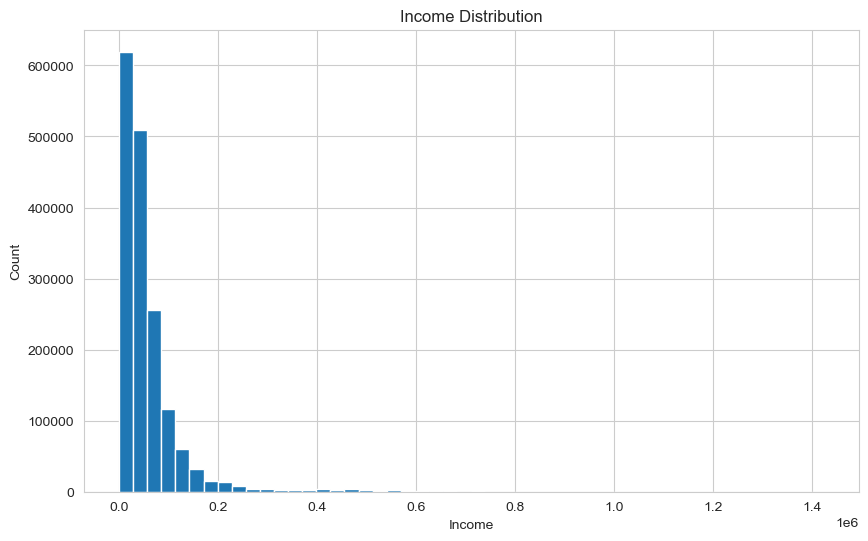

In [19]:
plt.hist(income_df['PINCP'],bins = 50)
plt.xlabel("Income")
plt.ylabel("Count")
plt.title('Income Distribution')
plt.show()


In [26]:
mean_income_by_gender = income_df.groupby("SEX")["PINCP"].mean()
mean_income_by_gender

SEX
1.0    67762.889827
2.0    44605.279921
Name: PINCP, dtype: float64

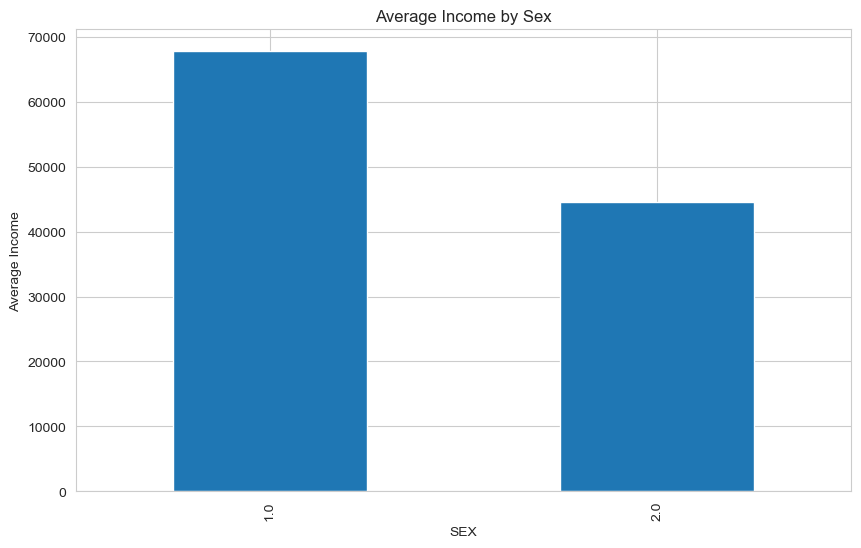

In [30]:
mean_income_by_gender.plot(kind='bar')
plt.ylabel('Average Income')
plt.title('Average Income by Sex')
plt.show()

In [ ]:
# there are some very high earners in SEX=1 pulling the average way up --> median gives a better idea because of the skew 
median_income_by_gender = income_df.groupby("SEX")["PINCP"].median()
median_income_by_gender

SEX
1.0    45000.0
2.0    32000.0
Name: PINCP, dtype: float64

In [32]:
# Race code 1.0 ==> White alone

income_df['RAC1P'].value_counts()


RAC1P
1.0    1298126
2.0     147573
6.0      96399
8.0      62877
9.0      41815
3.0      11887
7.0       2813
5.0       2104
4.0        906
Name: count, dtype: int64

In [36]:
income_by_race  = income_df.groupby('RAC1P')['PINCP'].mean()
income_by_race

RAC1P
1.0    59324.743404
2.0    40088.770073
3.0    37304.606713
4.0    32499.944812
5.0    35499.995247
6.0    68932.584508
7.0    42369.001066
8.0    34475.053708
9.0    45689.502858
Name: PINCP, dtype: float64

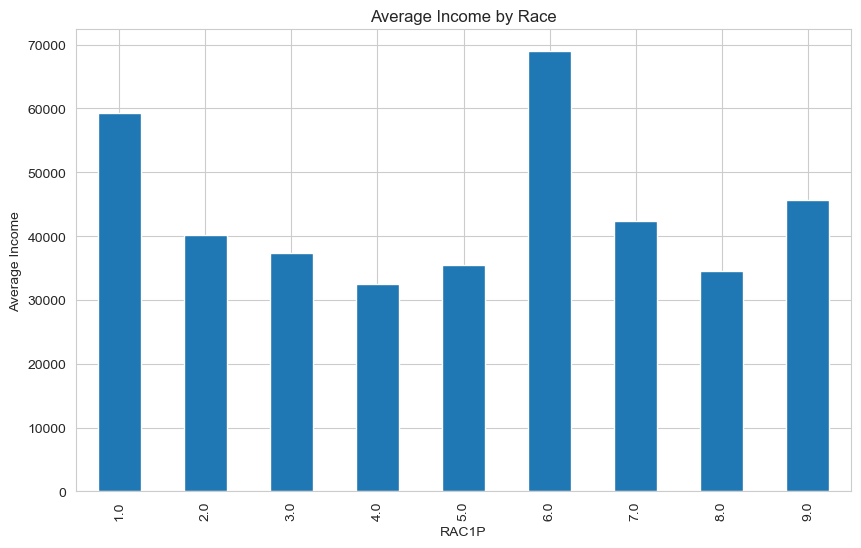

In [ ]:
# 6.0 indicates asian  ==> Asian tend to earn more ; least ==> 4.0 = Alaska Native 
income_df.groupby('RAC1P')['PINCP'].mean().plot(kind='bar')
plt.ylabel('Average Income')
plt.title('Average Income by Race')
plt.show()

In [43]:
income_df.groupby(['SEX', 'RAC1P'])['PINCP'].mean()


SEX  RAC1P
1.0  1.0      71564.376856
     2.0      43034.223324
     3.0      42321.759376
     4.0      32873.083512
     5.0      40641.373080
     6.0      81330.634580
     7.0      47381.297814
     8.0      38888.345400
     9.0      52370.746725
2.0  1.0      45683.533129
     2.0      37519.584172
     3.0      32146.210203
     4.0      32103.006834
     5.0      29791.364092
     6.0      56262.789941
     7.0      36929.414381
     8.0      28964.002861
     9.0      38904.886008
Name: PINCP, dtype: float64

In [44]:
pivot = income_df.pivot_table(values='PINCP', index='RAC1P', columns='SEX', aggfunc='mean')


In [45]:
pivot

SEX,1.0,2.0
RAC1P,,
1.0,71564.376856,45683.533129
2.0,43034.223324,37519.584172
3.0,42321.759376,32146.210203
4.0,32873.083512,32103.006834
5.0,40641.373080,29791.364092
6.0,81330.634580,56262.789941
7.0,47381.297814,36929.414381
8.0,38888.345400,28964.002861
9.0,52370.746725,38904.886008


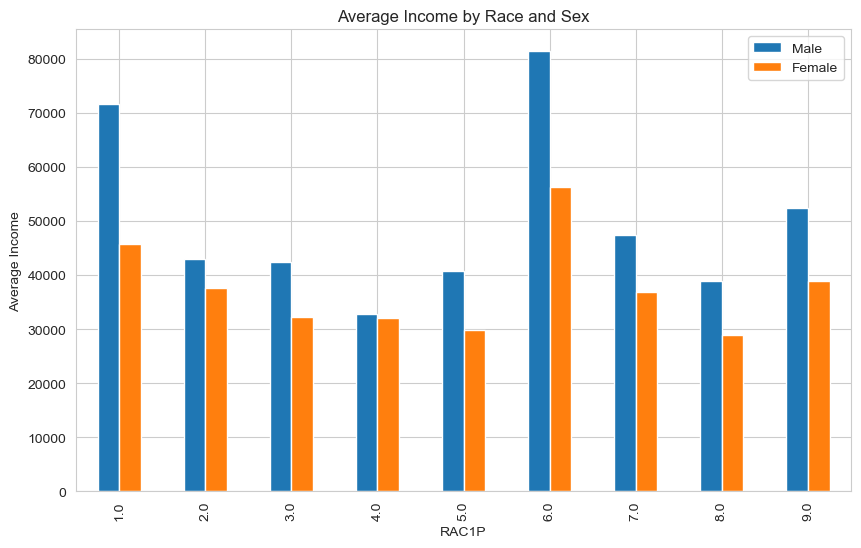

In [ ]:
# even within the backgrounds that make a lower income -- women are ofen making even lower ; certain race + gender combos are worse off 
pivot.plot(kind='bar', figsize=(10,6))
plt.ylabel('Average Income')
plt.title('Average Income by Race and Sex')
plt.legend(['Male', 'Female'])  
plt.show()

## Next: ##
Try other combinations:

Income by age?
Income by education level?
How do missing values look?
Anything weird or surprising?

 

In [49]:
income_df.columns

Index(['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX',
       'RAC1P', 'PINCP'],
      dtype='object')

In [56]:
income_by_age = income_df.groupby("AGEP")["PINCP"].mean()
income_by_age

AGEP
17.0     4264.972672
18.0     6170.738336
19.0     8422.694238
20.0    11733.360741
21.0    14087.777703
            ...     
92.0    55350.242424
93.0    67163.623188
94.0    70031.244444
95.0    58460.340909
96.0    49777.142857
Name: PINCP, Length: 80, dtype: float64

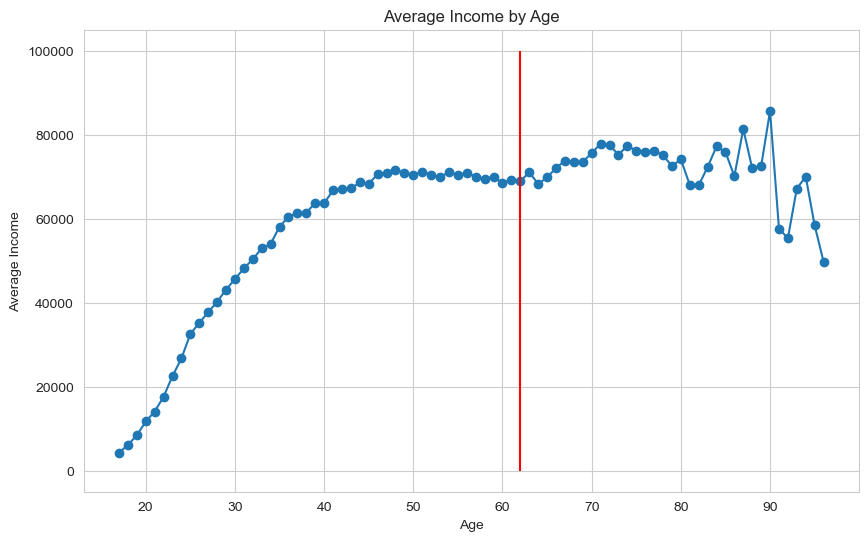

In [ ]:
# weird --> why does incme keep increasing even after average US retirement age(62)?? 
plt.plot(income_by_age.index, income_by_age.values, marker='o')
plt.xlabel("Age")
plt.ylabel("Average Income")
plt.title("Average Income by Age")
plt.grid(True)
plt.vlines(x=62, ymin=0, ymax=100000, colors='r', linestyles='solid')
plt.show()

--> need to review income by age 

## Average income by age and gender 